**Goal: Given a function, how can we find it's minimum value**

Let x be a vaiable with can take any value from -inf to +Inf. We can think of x as the x axis.
Now let y = x^2.  
This means that for any value of x (say 2) we just double it to get y. (2 * 2 = 4).  
y = 2x is rule we have defined. We can also call it a function (y is a function of x; as value of y depend solely on the value of x).

We know x looks like the x-axis, but how does y look. lets plot it.

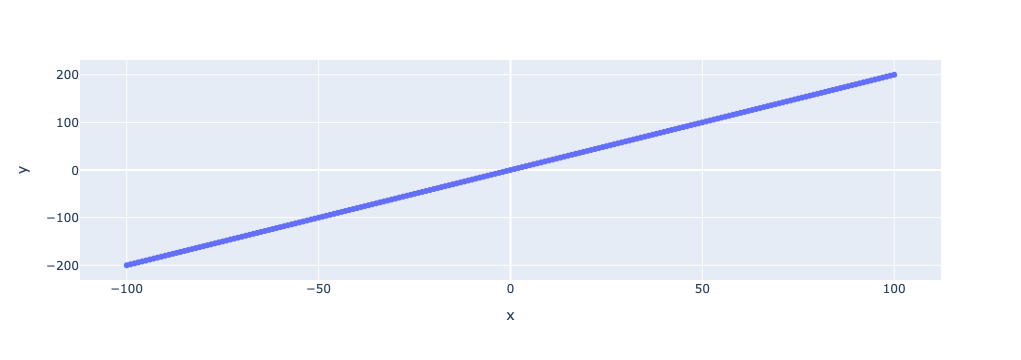

In [29]:
import torch
import pandas as pd
import plotly.express as px

x = torch.arange(-100, 100+1, 1)
y = 2 * x 

px.scatter(x=x, y=y)

Its a line which is going upwards as x increases!   
Now lets think why that the case. Lets investigate a few values of x and they corresponding y values. 

In [19]:
y_func = pd.DataFrame({
    "x" : x,
    "y" : y,
})

y_func["x change"] = y_func["x"] - y_func["x"].shift(1)
y_func["y change"] = y_func["y"] - y_func["y"].shift(1)

y_func.loc[y_func["x"].isin(range(0,11))].tail(10)

,x,y,x change,y change
101,1,2,1.0,2.0
102,2,4,1.0,2.0
103,3,6,1.0,2.0
104,4,8,1.0,2.0
105,5,10,1.0,2.0
106,6,12,1.0,2.0
107,7,14,1.0,2.0
108,8,16,1.0,2.0
109,9,18,1.0,2.0
110,10,20,1.0,2.0


In our table above if x1 = 5 & x2 = 6, y1 = 10 and y2 = 12. 
This implies that if we move one unit along x axis (6-5), we automatically move 2 unit along upwards along the y axis.
For each point we can see that if the value of x increases by 1, the value of y increases by 2. 

Let's see why that happens. Consider 2 values of x.
- x = x1, then y = 2 * x1
- x = x2, then y = 2 * x2
- Here x2 > x1

Then,
- Increase in x = Distance moved along x-axis towards the right
    -  Increase in x = x2 - x1
- Increase in y = Due to movement in x axis, how much did we move along the y-axis (upwards)
    - = y2 - y1 = 2 * x2 - 2  * x1 = 2 * (x2 - x1)

Notice that we moved along y-axis 2 times of how much we moved along the x axis!
More importantly, we did not specify what is the difference between x2 and x1. This implies that for any increase along the x-axis towards the right we will always move 2 time upward along the y axis.  

If x = 6.0 and x2 = 6.1; y1 = 6.0 * 2 = 12.0 and y2 = 6.1 * 2 = 12.2
- Increase in x (movement along x axis going from x1 to x2) 
    - = 6.1 - 6 = 0.1
- Increase in y (movement along x axis going from x1 to x2) 
    - = 12.2 - 12 = 0.2 = 2 * 0.1 = 2 * increase in x

This is why y = 2x is a line! And, the line "grows" by a factor of 2!

Why is it a line:
> Because y moves up by the same factor for every movement to the right. Since this factor is always the same, the graph never bends and forms a straight line. In the example below we will see what happens when the slope is not constant 

Growth factor of 2:  
> As we take a step towards the right of x axis, we move 2 times as much upward along the y axis. Also, this is irrespective of how big a step we take towards right side of x-axis.  
Also, if we keep increasing x the value of y keeps increasing. This is why we see y = 2x growing upwards as we move towards the right of x axis.

Hence, growth can be defined as $\text{Growth or Slope} = \frac{\text{increase in } y}{\text{increase in } x}$
The above formula is intutive. For a line, how fast it grows depends on how quickly y increase when x is moved by a little bit to the right of x-axis. If y increase too much for a small change in x, the line will be steeper. 

Hence, increase in y (rise)/ increase in x (run) gives us a constant factor for a line. Higher the value of factor (slope) steeper the line. 

# Negative slope

What would a negative slope imply? Its actually quite simple.  
The negative sign indicates that the line goes downward as the value of x increase.  
Lets consider another function: z = -2x

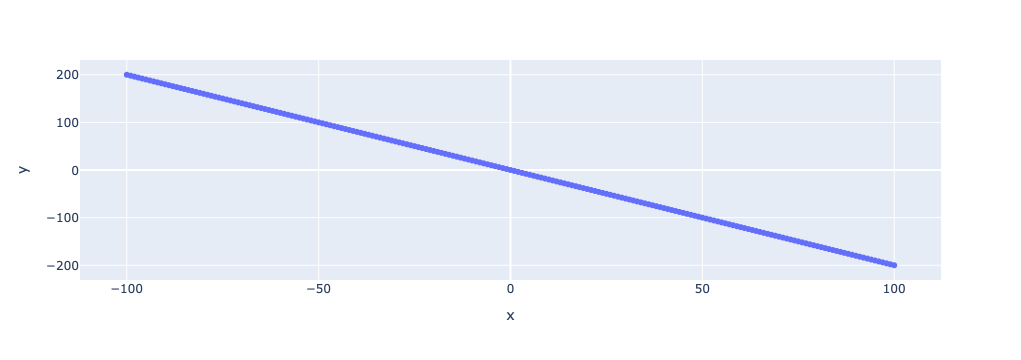

In [26]:
x = torch.arange(-100, 100+1, 1)
z = x * -2

px.scatter(x=x, y=z)

In [28]:
z_func = pd.DataFrame({
    "x" : x,
    "y" : z,
})

z_func["x change"] = z_func["x"] - z_func["x"].shift(1)
z_func["y change"] = z_func["y"] - z_func["y"].shift(1)

z_func.loc[z_func["x"].isin(range(0,11))].tail(10)

,x,y,x change,y change
101,1,-2,1.0,-2.0
102,2,-4,1.0,-2.0
103,3,-6,1.0,-2.0
104,4,-8,1.0,-2.0
105,5,-10,1.0,-2.0
106,6,-12,1.0,-2.0
107,7,-14,1.0,-2.0
108,8,-16,1.0,-2.0
109,9,-18,1.0,-2.0
110,10,-20,1.0,-2.0


We observe that:
1. Now the value of y decreases by a factor of 2 as the value of x increases
2. Considering any 2 value of x in the table, slope = -2
Hence, negative slope indicates negative growth (as x increase, y decreases) and the slope tells us how fast the decrease is (steepness of decrease in the value of y)

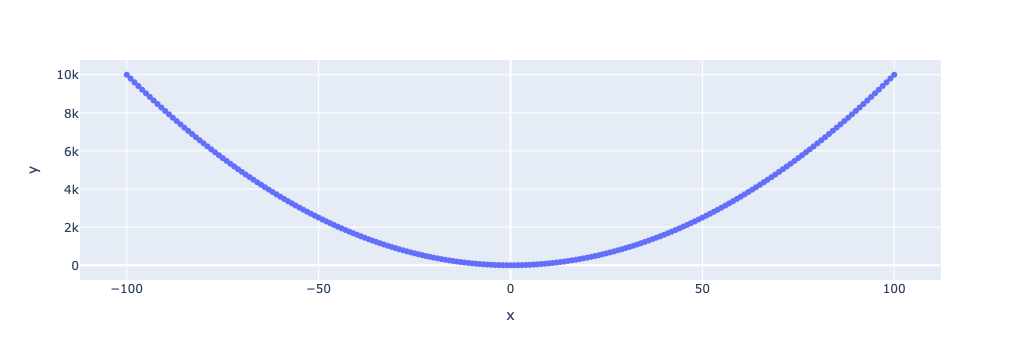

In [14]:
x = torch.arange(-100, 100+1, 1)
z = x ** 2

px.scatter(x=x, y=z)

It looks like a curve! One intution for the curve is that as the value of x gets large the square of the number grows much more than the number smaller to it. Hence, the "growth" is not the same for larger numbers

In [13]:
example = pd.DataFrame({
    "x" : x,
    "y" : y,
})
example["Difference"] = example["x"] - example["y"]
example.tail(10)

,x,y,Difference
191,91,8281,-8190
192,92,8464,-8372
193,93,8649,-8556
194,94,8836,-8742
195,95,9025,-8930
196,96,9216,-9120
197,97,9409,-9312
198,98,9604,-9506
199,99,9801,-9702
200,100,10000,-9900


Note: If the growth is same, we get a straight line.

Now lets focus on this growth